# Spatial Outlier Detection Methods Analysis
## Using Voronoi Diagrams as Neighborhood Definition

**Author:** Rocío Guerrero  
**Keywords:** outlier detection, Voronoi diagram, geospatial, GBSO, SWOD, LOF, Python

---

This notebook demonstrates three spatial outlier detection algorithms applied to geolocated data.
The key innovation is the use of the **Voronoi diagram** to define the neighborhood of each point,
replacing the classical Euclidean distance threshold approach.

The three methods implemented are:
- **GBSO** – Graph-Based Spatial Outlier Detection (Shekhar et al., 2001)
- **SWOD** – Spatial Weighted Outlier Detection (Kou et al., 2006)
- **Spatial LOF** – Local Outlier Factor adapted for spatial data (Breunig et al., 2000)


## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy.spatial import Voronoi, voronoi_plot_2d, distance
from scipy.stats import gamma

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Synthetic Dataset

We use a small synthetic dataset of 8 geolocated monitoring stations in South Florida,
with associated lead emission values. One point (`o5`) has a clearly anomalous value (2.86)
compared to its neighbors, making it a ground-truth outlier for validation.


In [2]:
# Geographic coordinates [latitude, longitude]
x = [25.72548, 25.79358, 25.79681, 25.859773, 25.873889, 25.881927, 25.9315, 26.09083]
y = [-80.31393, -80.19573, -80.39718, -80.341431, -80.372222, -80.253823, -80.20615, -80.14226]
labels = ['o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'o7', 'o8']

# Lead emission values (non-spatial attribute)
lead = np.array([0.0368, 0.0841, 0.027, 0.0, 2.86, 0.0, 0.0344, 0.0499])

COORDS = np.array(list(zip(x, y)))

df = pd.DataFrame({'Label': labels, 'Latitude': x, 'Longitude': y, 'Lead_Emissions': lead})
print(df.to_string(index=False))


Label  Latitude  Longitude  Lead_Emissions
   o1 25.725480 -80.313930          0.0368
   o2 25.793580 -80.195730          0.0841
   o3 25.796810 -80.397180          0.0270
   o4 25.859773 -80.341431          0.0000
   o5 25.873889 -80.372222          2.8600
   o6 25.881927 -80.253823          0.0000
   o7 25.931500 -80.206150          0.0344
   o8 26.090830 -80.142260          0.0499


## 3. Voronoi Diagram and Neighborhood Construction

The Voronoi diagram partitions the plane into convex polygonal regions, one per point.
Two points are considered **neighbors** if and only if they share a Voronoi edge.
This gives a variable number of neighbors per point, determined by the geometry of the data.

> **Definition:** For a set of points $O = \{o_1, ..., o_n\}$, the Voronoi cell $V(o_i)$ is
> the set of all points $p$ closer to $o_i$ than to any other $o_j$:
> $V(o_i) = \{p \mid dist(o_i, p) \leq dist(o_j, p),\; orall j 
eq i\}$


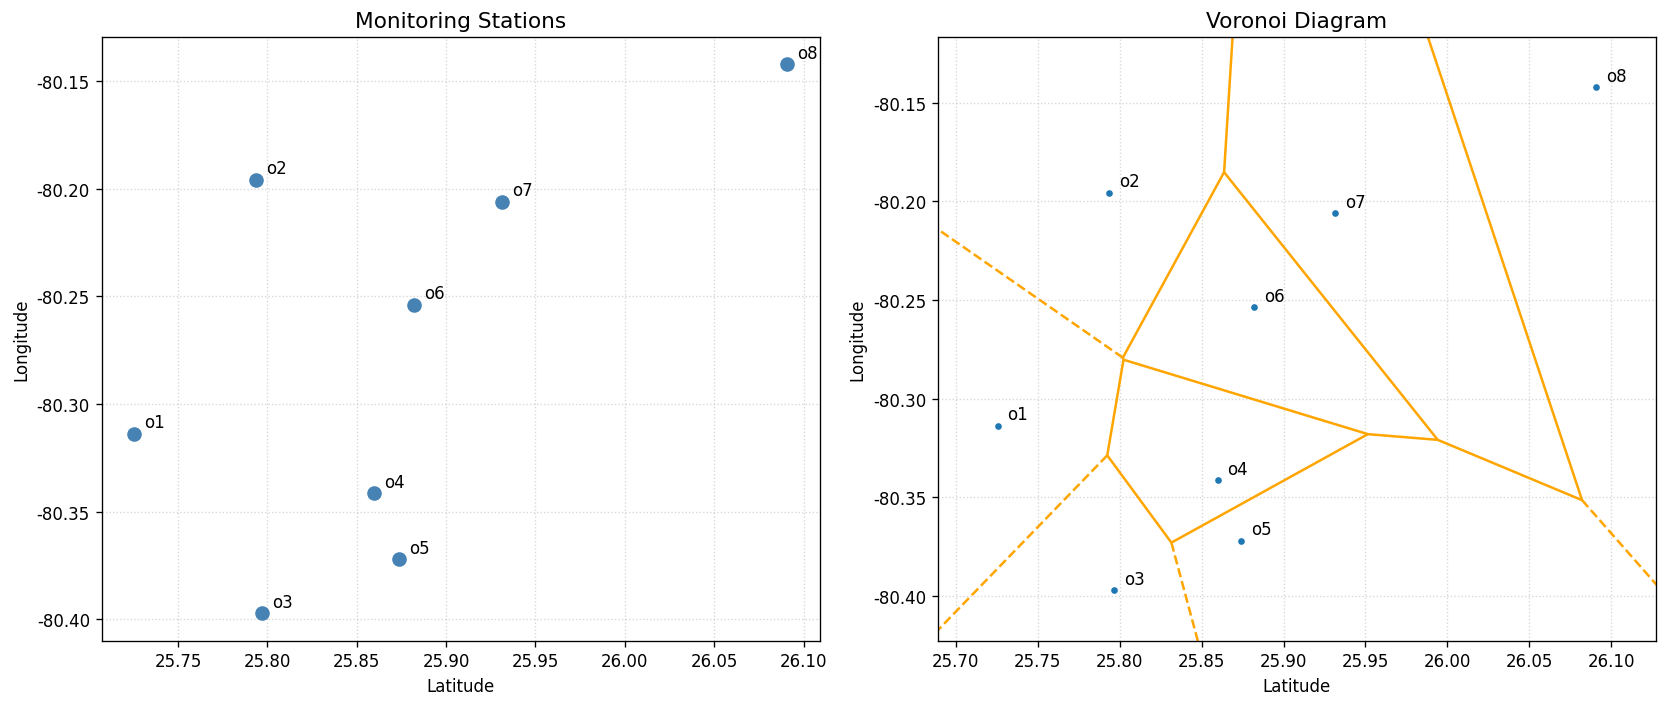

Voronoi diagram generated.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: raw points
ax = axes[0]
ax.scatter([c[0] for c in COORDS], [c[1] for c in COORDS], s=60, color='steelblue', zorder=3)
for i, (xi, yi) in enumerate(zip(x, y)):
    ax.annotate(labels[i], (xi, yi), textcoords="offset points", xytext=(6, 4), fontsize=10)
ax.set_title('Monitoring Stations', fontsize=13)
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.grid(True, linestyle=':', alpha=0.5)

# Right: Voronoi diagram
ax2 = axes[1]
vor = Voronoi(COORDS)
voronoi_plot_2d(vor, ax=ax2, show_vertices=False, line_colors='orange',
                line_width=1.5, point_size=6)
for i, (xi, yi) in enumerate(zip(x, y)):
    ax2.annotate(labels[i], (xi, yi), textcoords="offset points", xytext=(6, 4), fontsize=10)
ax2.set_title('Voronoi Diagram', fontsize=13)
ax2.set_xlabel('Latitude')
ax2.set_ylabel('Longitude')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('voronoi_diagram.png', bbox_inches='tight')
plt.show()
print("Voronoi diagram generated.")


### 3.1 Building the Neighbor List from the Voronoi Graph

The `ridge_points` attribute of SciPy's `Voronoi` object returns pairs of indices of
neighboring points. We load these into a NetworkX graph to extract the adjacency matrix,
from which we derive the neighbor list `Vnn` for each observation.


In [4]:
def voronoi_neighbors(coords, values):
    size = len(coords)
    DV = Voronoi(coords, qhull_options="QJ")
    edges = DV.ridge_points

    nodes = sorted(set(node for edge in edges for node in edge))
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    mx_veins = nx.adjacency_matrix(G).toarray().astype(float)
    Vnn = [list(np.where(mx_veins[i, :] == 1)[0]) for i in range(size)]
    k = mx_veins.sum(0)

    dist_points = distance.cdist(coords, coords, 'euclidean')

    y_i = [values[edges[i, 0]] for i in range(len(edges))]
    y_j = [values[edges[j, 1]] for j in range(len(edges))]
    y_i_y_j = np.array(list(zip(y_i, y_j)))
    dist_yij = np.linalg.norm(y_i_y_j, axis=1)

    ei = [edges[i, 0] for i in range(len(edges))]
    ej = [edges[j, 1] for j in range(len(edges))]
    edges_yij = tuple(zip(ei, ej))
    dict_values = dict(zip(edges_yij, dist_yij))

    dist_values = np.full((size, size), np.nan)
    for key, val in dict_values.items():
        dist_values[key] = val
        dist_values[key[1], key[0]] = val

    return dist_points, dist_values, Vnn, k

dist_points, dist_values, Vnn, k = voronoi_neighbors(COORDS, lead)

print("Voronoi neighbors (Vnn):")
for i, neighbors in enumerate(Vnn):
    print(f"  {labels[i]}: neighbors = {[labels[n] for n in neighbors]}  (k={int(k[i])})")


Voronoi neighbors (Vnn):
  o1: neighbors = ['o2', 'o3', 'o4', 'o6']  (k=4)
  o2: neighbors = ['o1', 'o6', 'o7', 'o8']  (k=4)
  o3: neighbors = ['o1', 'o4', 'o5']  (k=3)
  o4: neighbors = ['o1', 'o3', 'o5', 'o6']  (k=4)
  o5: neighbors = ['o3', 'o4', 'o6', 'o7', 'o8']  (k=5)
  o6: neighbors = ['o1', 'o2', 'o4', 'o5', 'o7']  (k=5)
  o7: neighbors = ['o2', 'o5', 'o6', 'o8']  (k=4)
  o8: neighbors = ['o2', 'o5', 'o7']  (k=3)


## 4. Graph-Based Spatial Outlier Detection (GBSO)

GBSO computes the deviation of each observation from the mean of its Voronoi neighbors.
The score is then normalized using the global mean and standard deviation.
A point is flagged as an outlier if its normalized score exceeds a threshold $\theta \approx 2$
(corresponding to a 95% confidence interval).

$$S(o_i) = y_i - \frac{\sum_{j=1}^{k} y_j}{k_i} \qquad \text{Test:} \quad \left|\frac{S(o_i) - \mu}{\sigma}\right| > \theta$$


In [5]:
def GBSO(S, GBS, Y):
    AvgDist_Set = [Y[i] - np.mean(Y[GBS[i]]) for i in range(len(GBS))]
    mu = np.mean(AvgDist_Set)
    sigma = np.std(AvgDist_Set)
    return pd.Series(abs((np.array(AvgDist_Set) - mu) / sigma))

gbso_scores = GBSO(S=COORDS, GBS=Vnn, Y=lead)
print("GBSO Scores:")
for i, s in enumerate(gbso_scores):
    flag = " <-- OUTLIER" if s >= 2 else ""
    print(f"  {labels[i]}: {s:.4f}{flag}")


GBSO Scores:
  o1: 0.1169
  o2: 0.1549
  o3: 0.6876
  o4: 0.5113
  o5: 2.5182 <-- OUTLIER
  o6: 0.4027
  o7: 0.4970
  o8: 0.6913


## 5. Spatial Weighted Outlier Detection (SWOD)

SWOD weights the contribution of each neighbor by the inverse of its spatial distance,
computing a distance-weighted average of the non-spatial attribute. The outlier score
is the normalized deviation from this weighted average. The top $m$ scores (typically 5%
of the data) are considered outliers.

$$VnnAvg(o_i) = \sum_{j=1}^{k} y_j \cdot w_j \qquad w_j = \frac{x_j}{\sum_{r=1}^{k} x_r}$$
$$OF(o_i) = \left|\frac{diff(o_i) - \mu}{\sigma}\right|$$


In [6]:
def SWOD(X, Y, k):
    size = len(X)
    weight = [list(X[i, k[i]] / sum(X[i, k[i]])) for i in range(size)]
    NbrAvg = [sum(Y[k[i]] * weight[i]) for i in range(size)]
    diff = [Y[i] - NbrAvg[i] for i in range(size)]
    mu, sigma = np.mean(diff), np.std(diff)
    OF = np.array([abs((diff[i] - mu) / sigma) for i in range(size)])
    return pd.Series(OF)

swod_scores = SWOD(X=dist_points, Y=lead, k=Vnn)
m = max(1, round(len(COORDS) * 0.05))
top_outliers = (-swod_scores).argsort()[:m]
print(f"SWOD Scores (top {m} = outlier):")
for i, s in enumerate(swod_scores):
    flag = " <-- OUTLIER" if i in top_outliers else ""
    print(f"  {labels[i]}: {s:.4f}{flag}")


SWOD Scores (top 1 = outlier):
  o1: 0.1081 <-- OUTLIER
  o2: 0.1394
  o3: 0.6034
  o4: 0.1558
  o5: 2.4886
  o6: 0.4481
  o7: 0.6689
  o8: 0.8598


## 6. Spatial Local Outlier Factor (Spatial LOF)

LOF measures the local density of each point relative to its Voronoi neighbors.
A point with a much lower density than its neighbors receives a high LOF score,
indicating it is an outlier. Here, the Voronoi neighborhood replaces the classical
$k$-nearest neighbors based on Euclidean distance.

$$LRD(o_i) = \frac{1}{\frac{\sum_{p \in Vnn(o_i)} reach\_dist_k(o_i, p)}{|k(o_i)|}} \qquad LOF(o_i) = \frac{\sum_{p \in Vnn(o_i)} LRD(p)}{LRD(o_i) \cdot k(o_i)}$$


In [7]:
def spatial_LOF(dist, Vnn, k):
    size = len(Vnn)
    order = np.argsort(dist)
    idx_Vnn = [list(order[i, :len(Vnn[i])]) for i in range(size)]
    radius = np.array([dist[i, idx_Vnn[i][-1]] for i in range(size)])
    LRD = [np.mean(np.maximum(dist[i, idx_Vnn[i]], radius[idx_Vnn[i]])) for i in range(size)]
    rho = 1. / np.array(LRD)
    LOF = np.array([np.sum(rho[idx_Vnn[i]]) / rho[i] for i in range(size)])
    LOF *= 1. / k
    return pd.Series(LOF)

lof_scores = spatial_LOF(dist=dist_values, Vnn=Vnn, k=k)
print("Spatial LOF Scores:")
for i, s in enumerate(lof_scores):
    flag = " <-- OUTLIER" if s >= 2 else ""
    print(f"  {labels[i]}: {s:.4f}{flag}")


Spatial LOF Scores:
  o1: 1.0895
  o2: 1.0881
  o3: 0.8213
  o4: 1.0281
  o5: 1.4438
  o6: 0.7697
  o7: 1.0287
  o8: 0.8222


## 7. Visualization of Results

Each plot shows the monitoring stations as green dots (normal) and red dots (outliers).
The threshold for GBSO and LOF is $\theta = 2$; for SWOD the top $m = 5\%$ are flagged.


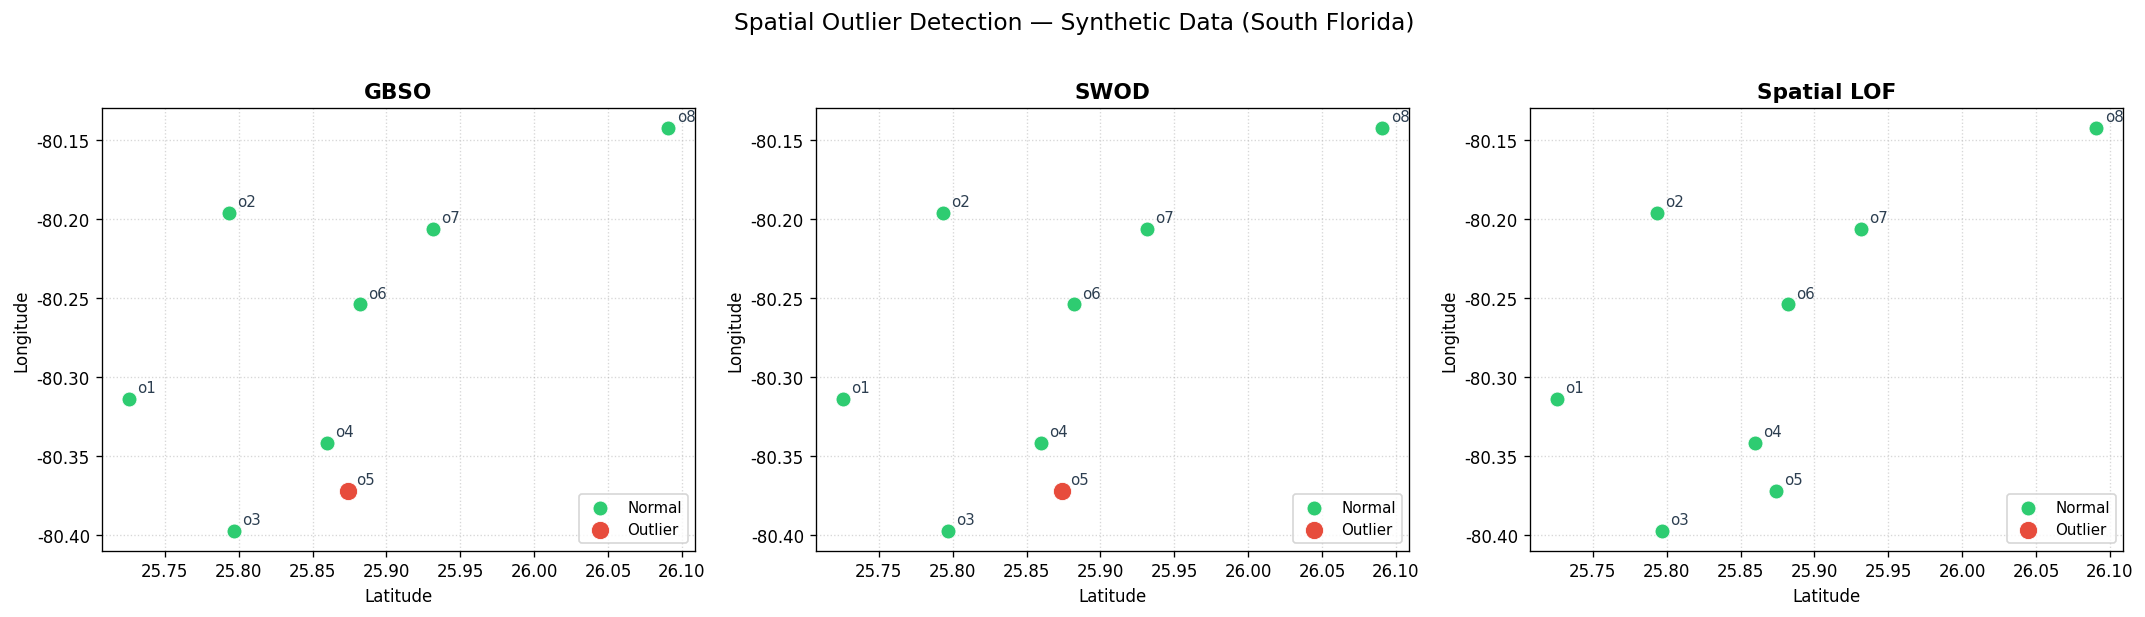

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
theta = 2

configs = [
    (gbso_scores, 'GBSO', 'threshold', theta),
    (swod_scores, 'SWOD', 'top_m', m),
    (lof_scores,  'Spatial LOF', 'threshold', theta),
]

for ax, (scores, title, mode, param) in zip(axes, configs):
    scores_arr = np.array(scores)
    ax.scatter(COORDS[:, 0], COORDS[:, 1], c='#2ecc71', s=80,
               edgecolors='white', linewidths=0.5, zorder=2, label='Normal')
    if mode == 'threshold':
        idx = np.where(scores_arr >= param)[0]
    else:
        idx = (-scores_arr).argsort()[:param]
    ax.scatter(COORDS[idx, 0], COORDS[idx, 1], c='#e74c3c', s=120,
               edgecolors='white', linewidths=0.5, zorder=3, label='Outlier')
    for i, (xi, yi) in enumerate(zip(x, y)):
        ax.annotate(labels[i], (xi, yi), textcoords="offset points",
                    xytext=(5, 4), fontsize=9, color='#2c3e50')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Longitude')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Spatial Outlier Detection — Synthetic Data (South Florida)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outlier_results.png', bbox_inches='tight')
plt.show()


## 8. Gamma Standardization for Score Comparison

Since the three models produce scores on different scales, we apply a **Gamma CDF
standardization** to map all scores to the $[0, 1]$ interval. This allows direct
comparison across models and the construction of a unified ranking.

$$\text{score}_{\gamma}(o_i) = \max\left(0,\; \frac{F_{\gamma}(s_i) - F_{\gamma}(\mu)}{1 - F_{\gamma}(\mu)}\right)$$


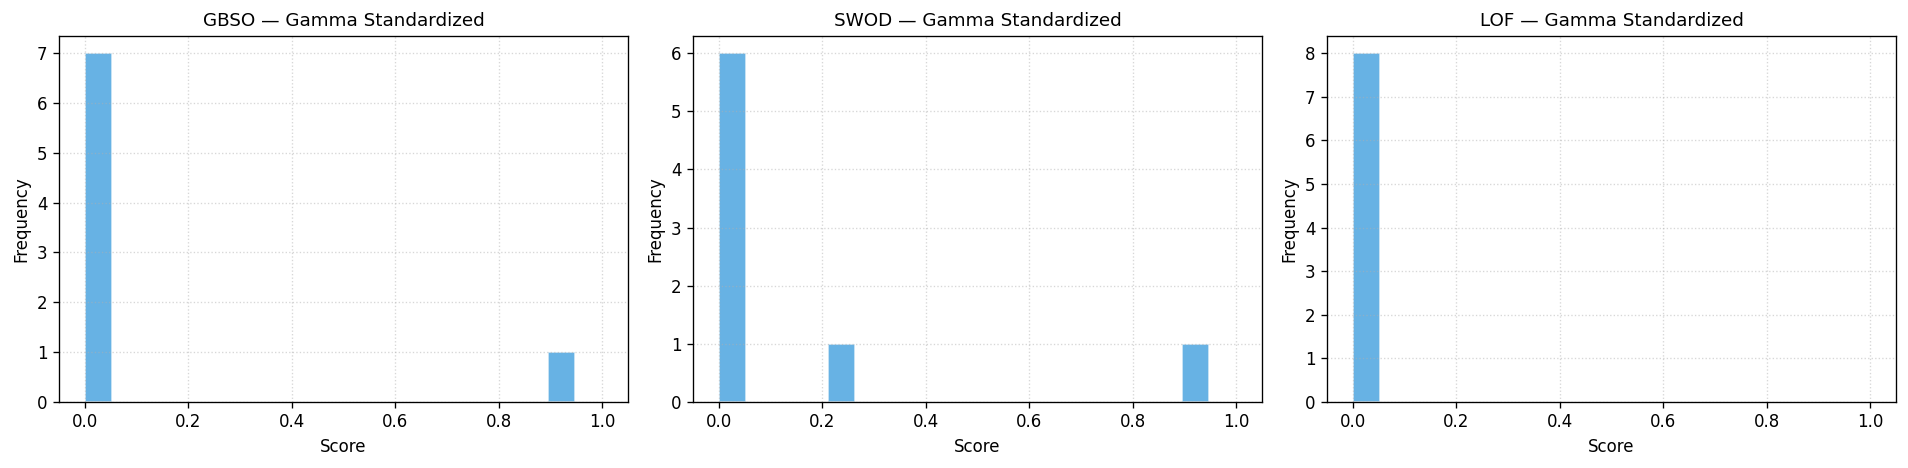

In [9]:
def gamma_standardization(Score):
    mu = np.mean(Score)
    sigma = np.std(Score)
    shape, scale = (mu**2) / (sigma**2), sigma / (mu**2)
    cdf = gamma.cdf(Score, a=shape, scale=1/scale)
    cdf_mu = gamma.cdf(mu, a=shape, scale=1/scale)
    return pd.Series(np.maximum(0, (cdf - cdf_mu) / (1 - cdf_mu)))

gbso_std = gamma_standardization(gbso_scores)
swod_std = gamma_standardization(swod_scores)
lof_std  = gamma_standardization(lof_scores)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bins = np.linspace(0, 1, 20)
for ax, (std_scores, title) in zip(axes, [
    (gbso_std, 'GBSO — Gamma Standardized'),
    (swod_std, 'SWOD — Gamma Standardized'),
    (lof_std,  'LOF — Gamma Standardized'),
]):
    ax.hist(np.round(std_scores, 4), bins=bins, color='#3498db', alpha=0.75, edgecolor='white')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.set_title(title, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('gamma_standardization.png', bbox_inches='tight')
plt.show()


## 9. Comparative Summary Table


In [10]:
summary = pd.DataFrame({
    'Point': labels,
    'Lead_Value': lead,
    'GBSO_Score': gbso_scores.round(4),
    'SWOD_Score': swod_scores.round(4),
    'LOF_Score':  lof_scores.round(4),
    'GBSO_Std':   gbso_std.round(4),
    'SWOD_Std':   swod_std.round(4),
    'LOF_Std':    lof_std.round(4),
})
summary = summary.sort_values('GBSO_Score', ascending=False)
print(summary.to_string(index=False))


Point  Lead_Value  GBSO_Score  SWOD_Score  LOF_Score  GBSO_Std  SWOD_Std  LOF_Std
   o5      2.8600      2.5182      2.4886     1.4438    0.9348    0.9464      0.0
   o8      0.0499      0.6913      0.8598     0.8222    0.0000    0.2531      0.0
   o3      0.0270      0.6876      0.6034     0.8213    0.0000    0.0000      0.0
   o4      0.0000      0.5113      0.1558     1.0281    0.0000    0.0000      0.0
   o7      0.0344      0.4970      0.6689     1.0287    0.0000    0.0000      0.0
   o6      0.0000      0.4027      0.4481     0.7697    0.0000    0.0000      0.0
   o2      0.0841      0.1549      0.1394     1.0881    0.0000    0.0000      0.0
   o1      0.0368      0.1169      0.1081     1.0895    0.0000    0.0000      0.0


## References

- **Schubert, E., Zimek, A., & Kriegel, H. P. (2014).** Local outlier detection reconsidered: a generalized view on locality with applications to spatial, video, and network outlier detection. *Data Mining and Knowledge Discovery, 28*(1), 190–237.
- **Shekhar, S., Lu, C. T., & Zhang, P. (2001).** Detecting graph-based spatial outliers: algorithms and applications. *Proceedings of the 7th ACM SIGKDD*, 371–376.
- **Kou, Y., Lu, C. T., & Chen, D. (2006).** Spatial weighted outlier detection. *Proceedings of the 2006 SIAM International Conference on Data Mining*, 614–618.
- **Breunig, M. M., Kriegel, H. P., Ng, R. T., & Sander, J. (2000).** LOF: identifying density-based local outliers. *Proceedings of the 2000 ACM SIGMOD*, 93–104.
- **Chandola, V., Banerjee, A., & Kumar, V. (2009).** Anomaly detection: A survey. *ACM Computing Surveys, 41*(3), 1–58.
